In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import missingno as msno


In [2]:
df =pd.read_csv('mlb_player_value.csv')

df.head()


,Player,Player_ID,Player_URL,Season,Age,Team,Lg,Pos,G,PA,...,OPS+_est,HR_Rate,BB_Rate,SO_Rate,RBI_per_Game,HR_per_Million,RBI_per_Million,OPS_per_Million,Salary_per_HR,Age_Group
0,Marcus Semien,543760,/api/v1/people/543760,2022,31,TEX,AL,2B,161,724,...,106.2,0.0359,0.0732,0.1657,0.516,1.0400,3.3200,0.0293,961538.0,Veteran (30-34)
1,Freddie Freeman,518692,/api/v1/people/518692,2022,32,LAD,NL,1B,159,708,...,160.1,0.0297,0.1186,0.1441,0.629,0.7778,3.7037,0.0340,1285714.0,Veteran (30-34)
2,Trea Turner,607208,/api/v1/people/607208,2022,29,LAD,NL,SS,160,708,...,128.1,0.0297,0.0636,0.1850,0.625,1.0000,4.7619,0.0385,1000000.0,Prime (25-29)
3,Vladimir Guerrero Jr.,665489,/api/v1/people/665489,2022,23,TOR,AL,1B,160,706,...,130.4,0.0453,0.0822,0.1643,0.606,4.0506,12.2785,0.1037,246875.0,U25
4,Francisco Lindor,596019,/api/v1/people/596019,2022,28,NYM,NL,SS,161,706,...,122.5,0.0368,0.0836,0.1884,0.665,0.8125,3.3438,0.0246,1230769.0,Prime (25-29)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2673 entries, 0 to 2672
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Player           2673 non-null   object 
 1   Player_ID        2673 non-null   int64  
 2   Player_URL       2673 non-null   object 
 3   Season           2673 non-null   int64  
 4   Age              2673 non-null   int64  
 5   Team             2673 non-null   object 
 6   Lg               2673 non-null   object 
 7   Pos              2673 non-null   object 
 8   G                2673 non-null   int64  
 9   PA               2673 non-null   int64  
 10  AB               2673 non-null   int64  
 11  R                2673 non-null   int64  
 12  H                2673 non-null   int64  
 13  2B               2673 non-null   int64  
 14  3B               2673 non-null   int64  
 15  HR               2673 non-null   int64  
 16  RBI              2673 non-null   int64  
 17  SB            

In [4]:
df.describe()

,Player_ID,Season,Age,G,PA,AB,R,H,2B,3B,...,lgSLG,OPS+_est,HR_Rate,BB_Rate,SO_Rate,RBI_per_Game,HR_per_Million,RBI_per_Million,OPS_per_Million,Salary_per_HR
count,2673.000000,2673.000000,2673.000000,2673.000000,2673.000000,2673.000000,2673.000000,2673.000000,2673.000000,2673.000000,...,2673.000000,2673.000000,2673.000000,2673.000000,2673.000000,2673.000000,2505.000000,2505.000000,2505.000000,2.029000e+03
mean,641105.192667,2023.487841,27.729892,75.916199,273.674149,245.130565,32.249532,60.035166,11.853348,1.002619,...,0.402910,78.903816,0.024278,0.077926,0.256041,0.332795,5.743772,22.195514,0.588860,5.744093e+05
std,53990.498220,1.128007,3.661428,51.108576,216.964474,193.527874,28.996532,51.845343,10.861239,1.633182,...,0.007170,55.103304,0.021778,0.047283,0.115659,0.197958,8.339595,27.522151,0.408965,1.109531e+06
min,405395.000000,2022.000000,19.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.394855,-100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.666700e+04
25%,621028.000000,2022.000000,25.000000,28.000000,72.000000,65.000000,7.000000,13.000000,2.000000,0.000000,...,0.394855,59.400000,0.008800,0.052000,0.192000,0.200000,0.701800,3.947400,0.154800,1.166670e+05
50%,663743.000000,2023.000000,27.000000,72.000000,230.000000,207.000000,24.000000,46.000000,9.000000,0.000000,...,0.399219,85.900000,0.023300,0.075500,0.243600,0.333000,2.500000,10.500000,0.675700,2.805560e+05
75%,672642.000000,2025.000000,30.000000,124.000000,454.000000,405.000000,53.000000,100.000000,20.000000,1.000000,...,0.403809,109.000000,0.035700,0.100000,0.300000,0.457000,6.839000,28.852500,0.910500,7.200000e+05
max,829272.000000,2025.000000,42.000000,163.000000,753.000000,671.000000,149.000000,217.000000,59.000000,17.000000,...,0.414158,567.000000,0.500000,1.000000,1.000000,3.000000,60.000000,149.333300,3.571400,2.200000e+07


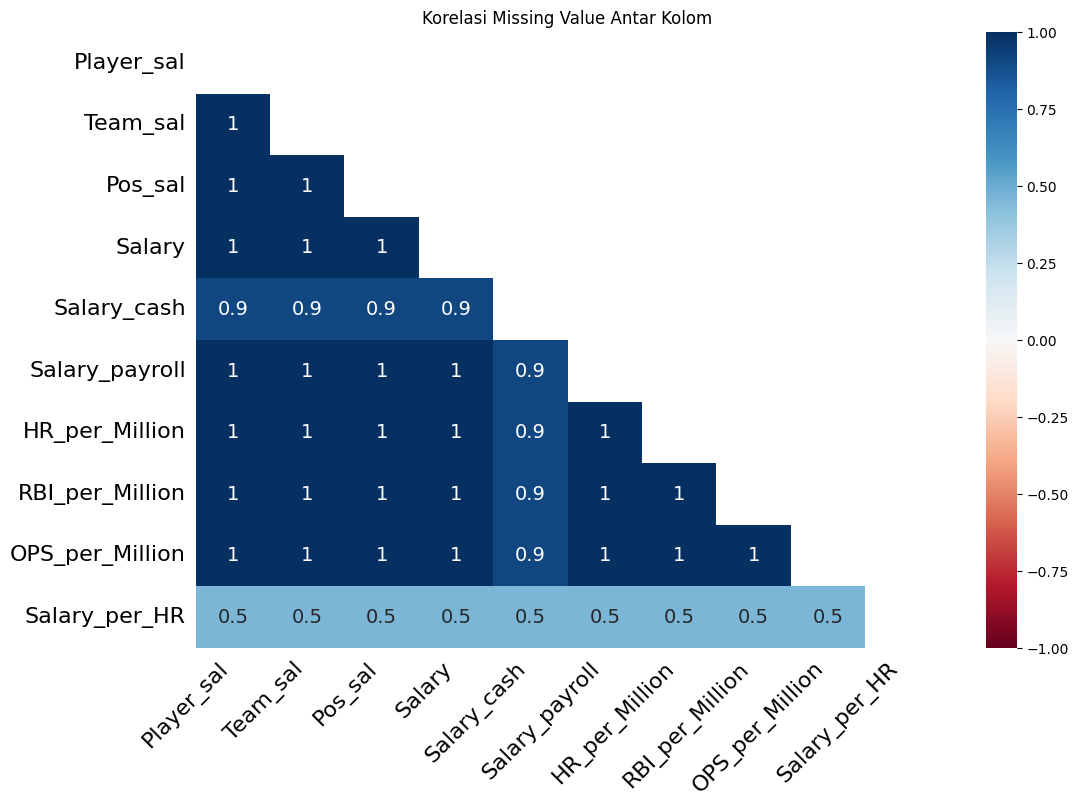

In [5]:
missing_cols = df.columns[df.isnull().any()]

# Visualisasi korelasi missing value
msno.heatmap(
    df[missing_cols],
    figsize=(12, 8)
)

plt.title("Korelasi Missing Value Antar Kolom")
plt.show()

dari visualisasi missing tersebut dapa kita ketahui bahwa missing value yang terjadi itu merupakan missing not at random karena semuanya berkaitan sangat erat untuk missingnya untuk mengatasi hal tersebut di code selanjutnya saya membuat sebuah fitur baru sebagai missing_flag

In [28]:
df["Salary_Missing"] = df["Salary"].isnull().astype(int)
df[["Salary", "Salary_Missing"]].head(20)

,Salary,Salary_Missing
0,25000000.0,0
1,27000000.0,0
2,21000000.0,0
3,7900000.0,0
4,32000000.0,0
5,15000000.0,0
6,825000.0,0
7,19000000.0,0
8,10000000.0,0
9,3950000.0,0


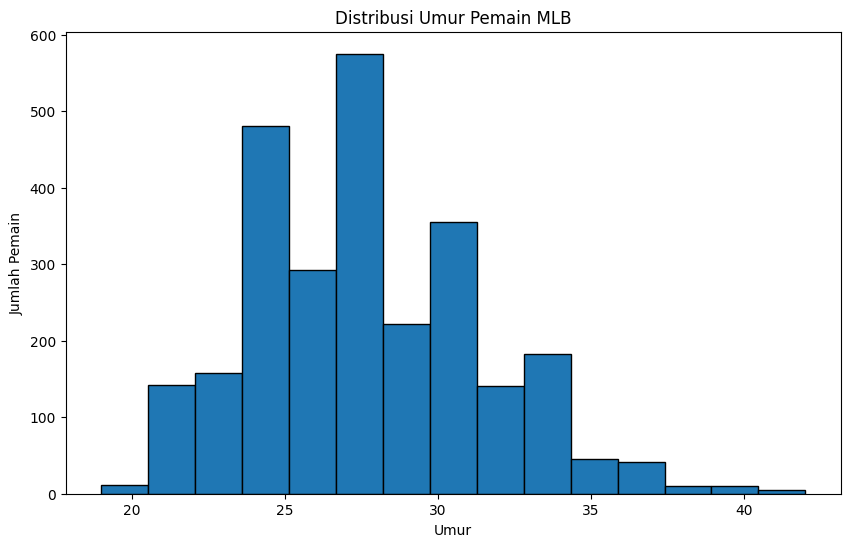

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df["Age"].dropna(), bins=15, edgecolor="black")

plt.title("Distribusi Umur Pemain MLB")
plt.xlabel("Umur")
plt.ylabel("Jumlah Pemain")

plt.show()

untuk distribusi dari age sendiri itu mendekati distribusi normal tetapi tidak masuk ke dalam distribusi normal karena nilai dari mean dan mediannya tidak sama hal tersebut dapat dilihat dengan jelas dari output cell describe yang mana meannya 27.7 dan mediannya 27

Text(0, 0.5, 'Jumlah Pemain')

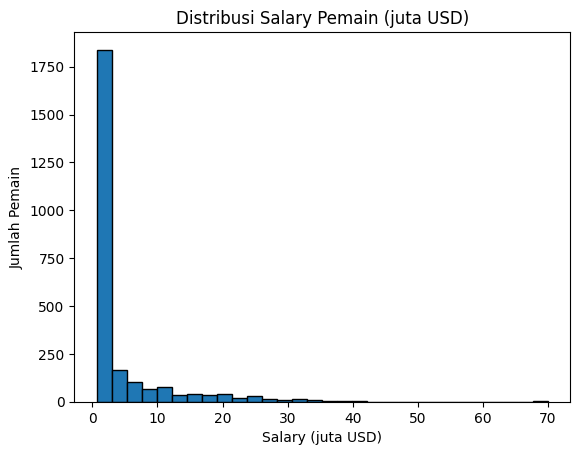

In [7]:
s = df["Salary"].dropna() / 1_000_000  # juta USD

plt.hist(s, bins=30, edgecolor="black")
plt.title("Distribusi Salary Pemain (juta USD)")
plt.xlabel("Salary (juta USD)")
plt.ylabel("Jumlah Pemain")



Text(0.5, 1.0, 'Distribusi Salary (log scale)')

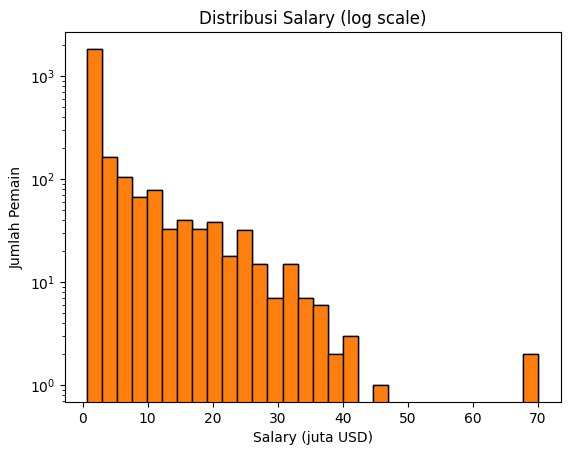

In [8]:
s = df["Salary"].dropna() / 1_000_000  # juta USD

plt.hist(s, bins=30, edgecolor="black")
plt.title("Distribusi Salary Pemain (juta USD)")
plt.xlabel("Salary (juta USD)")
plt.ylabel("Jumlah Pemain")
plt.hist(s, bins=30, edgecolor="black", log=True)
plt.title("Distribusi Salary (log scale)")

dari visualisasi tersebut dapat dilihat bahwa untuk persebarannya banyak outliers dan tidak termasuk ke distribusi normal karena persebarannya termasuk skew

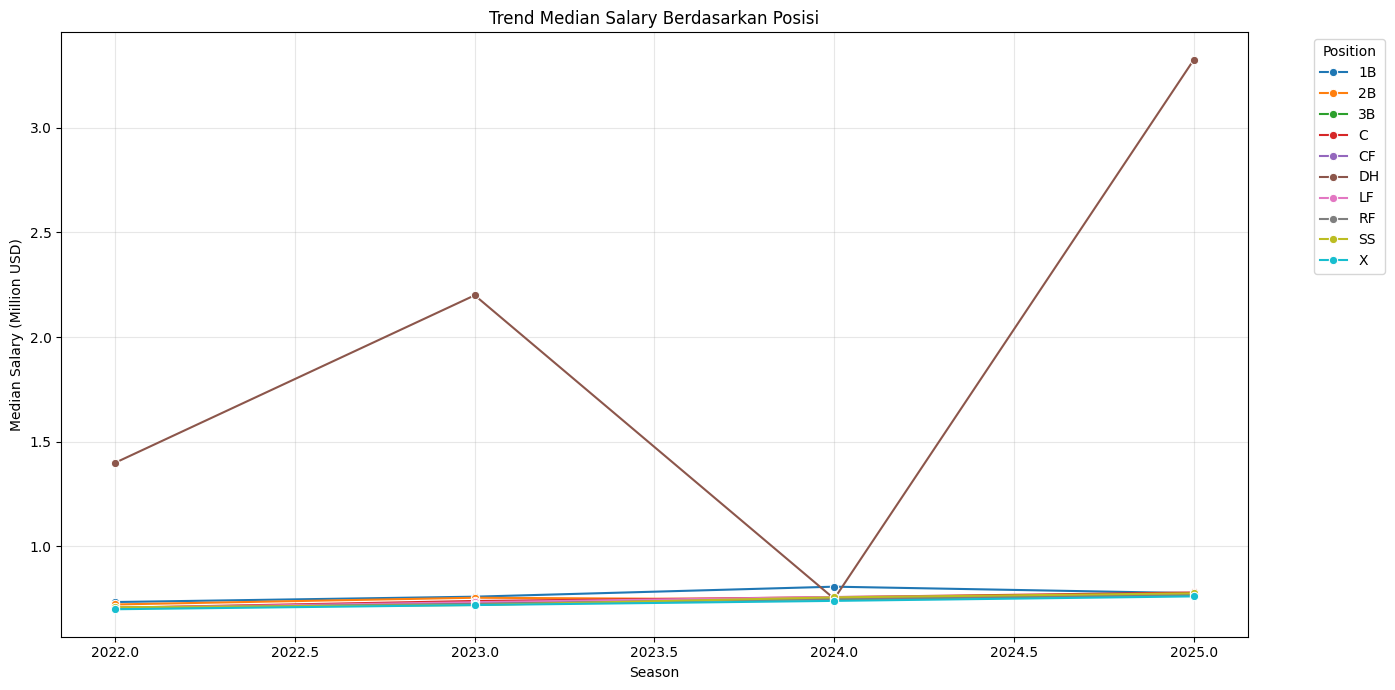

In [17]:
# Hitung jumlah pemain per posisi per season
pos_count = (
    df.groupby(["Season", "Pos"])
      .size()
      .reset_index(name="count")
)

# Ambil posisi yang punya minimal 10 pemain di SETIAP season
valid_pos = (
    pos_count.groupby("Pos")["count"]
    .min()
)

valid_pos = valid_pos[valid_pos >= 10].index

# Filter dataframe
df_pos = df[df["Pos"].isin(valid_pos)]

# Median salary per season dan posisi
salary_trend = (
    df_pos.groupby(["Season", "Pos"])["Salary"]
    .median()
    .reset_index()
)

salary_trend["Salary_Million"] = salary_trend["Salary"] / 1_000_000

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=salary_trend,
    x="Season",
    y="Salary_Million",
    hue="Pos",
    marker="o"
)

plt.title("Trend Median Salary Berdasarkan Posisi")
plt.xlabel("Season")
plt.ylabel("Median Salary (Million USD)")

plt.legend(
    title="Position",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
count_pos = (
    df.groupby(["Season", "Pos"])
    .size()
    .reset_index(name="Player_Count")
)

print(count_pos[count_pos["Pos"] == "DH"])

    Season Pos  Player_Count
5     2022  DH            51
16    2023  DH            48
27    2024  DH            40
38    2025  DH            47


In [11]:
dh_salary = (
    df[df["Pos"] == "DH"]
    .groupby("Season")["Salary"]
    .agg(["count", "median", "mean", "min", "max"])
)

print(dh_salary)

        count     median          mean       min         max
Season                                                      
2022       48  1400000.0  5.972281e+06  700000.0  32000000.0
2023       43  2200000.0  7.066621e+06  720000.0  32000000.0
2024       37   750050.0  7.416126e+06  740000.0  70000000.0
2025       45  3325000.0  9.808367e+06  760000.0  70000000.0


dari visualisasi dan sorting yang sudah dilakukan memperlihatkan bahwa jumlah pemain dh sangat sedikit sehingga trend median salary nya sangat rentan karena sangat mungkin nilai salary player nya termasuk ke dalam kategori tinggi

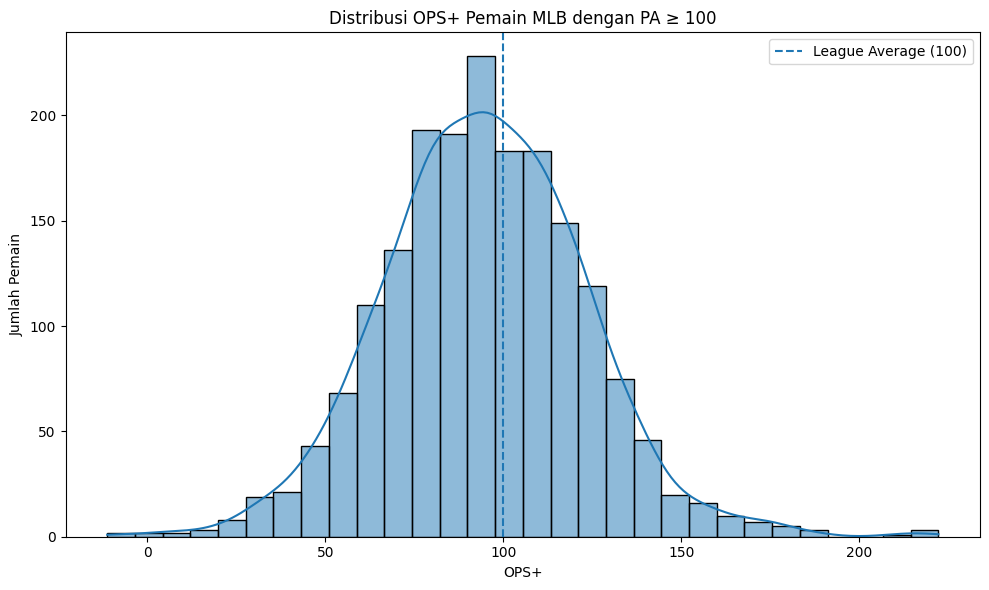

In [18]:
df_ops = df[df["PA"] >= 100]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_ops,
    x="OPS+",
    bins=30,
    kde=True
)

plt.axvline(
    100,
    linestyle="--",
    label="League Average (100)"
)

plt.title("Distribusi OPS+ Pemain MLB dengan PA ≥ 100")
plt.xlabel("OPS+")
plt.ylabel("Jumlah Pemain")
plt.legend()

plt.tight_layout()
plt.show()

untuk persebaran datanya mendekati distribusi normal tetapi masih ada sedikit data yang menunjukkan ada nya outliers dari distribusi data tersebut

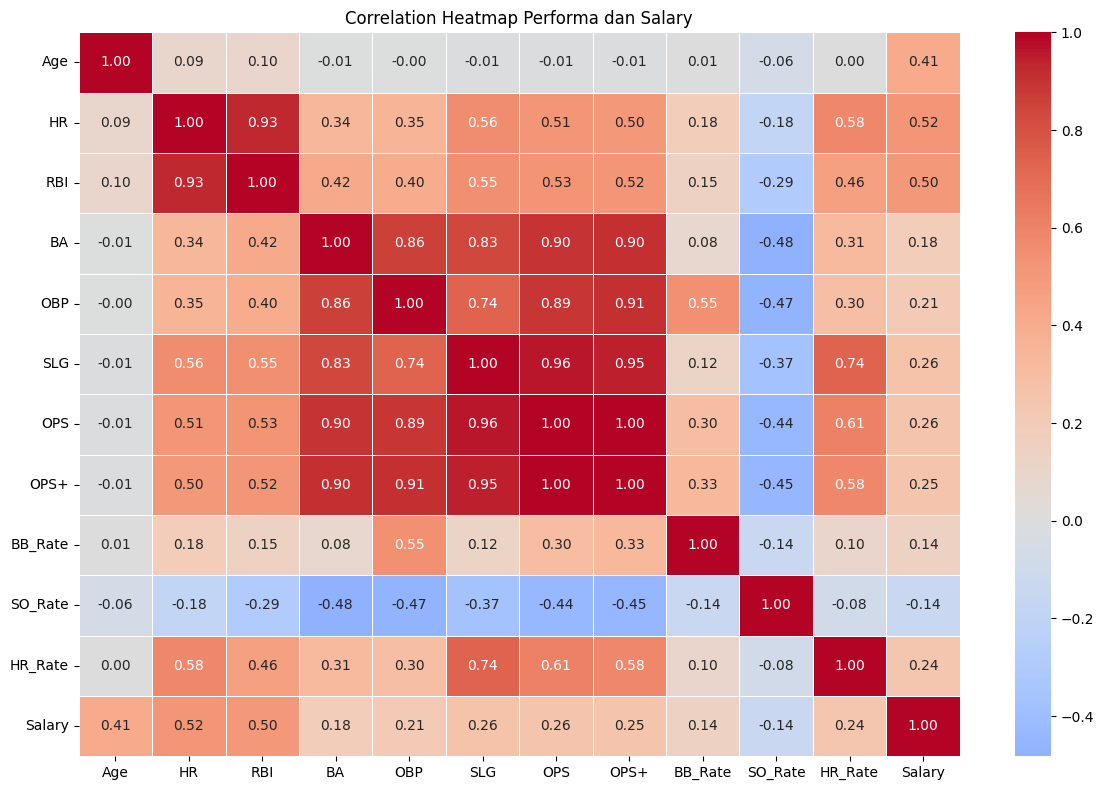

In [19]:
features_value = [
    "Age",
    "HR",
    "RBI",
    "BA",
    "OBP",
    "SLG",
    "OPS",
    "OPS+",
    "BB_Rate",
    "SO_Rate",
    "HR_Rate",
    "Salary"
]

corr_value = df[features_value].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_value,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap Performa dan Salary")
plt.tight_layout()
plt.show()

dari heatmap tersebut jika kita liha korelasi terhadap fitur salary ada beberapa yang berkorelasi cukup tinggi antara HR sebagai jumlah home run dan RBI sebagai jumlah run yang dihasilkan oleh pukulan pemain. alasan fitur tersebut berkorelasi adalah karena HR dan RBI merupakan peforma yang ditunjukkan oleh pemain 

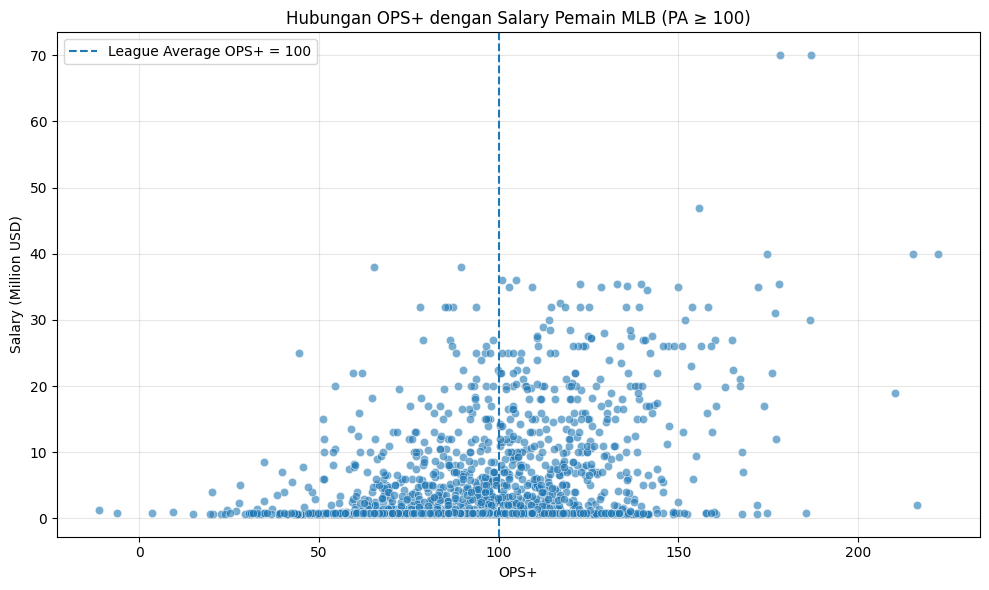

In [21]:
df_filtered = df[
    (df["PA"] >= 100) &
    (df["OPS+"].notna()) &
    (df["Salary"].notna())
].copy()

df_filtered["Salary_Million"] = (
    df_filtered["Salary"] / 1_000_000
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_filtered,
    x="OPS+",
    y="Salary_Million",
    alpha=0.6
)

plt.axvline(
    x=100,
    linestyle="--",
    label="League Average OPS+ = 100"
)

plt.title("Hubungan OPS+ dengan Salary Pemain MLB (PA ≥ 100)")
plt.xlabel("OPS+")
plt.ylabel("Salary (Million USD)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

dari persebaran data tersebut menunjukkan bahwa ops+ yang semakin tinggi akan membuat salary lebih tinggi akan tetapi tidak semuanya karena korelasi antar kedua fitur tidak besar dan terlalu berpengaruh satu sama lain

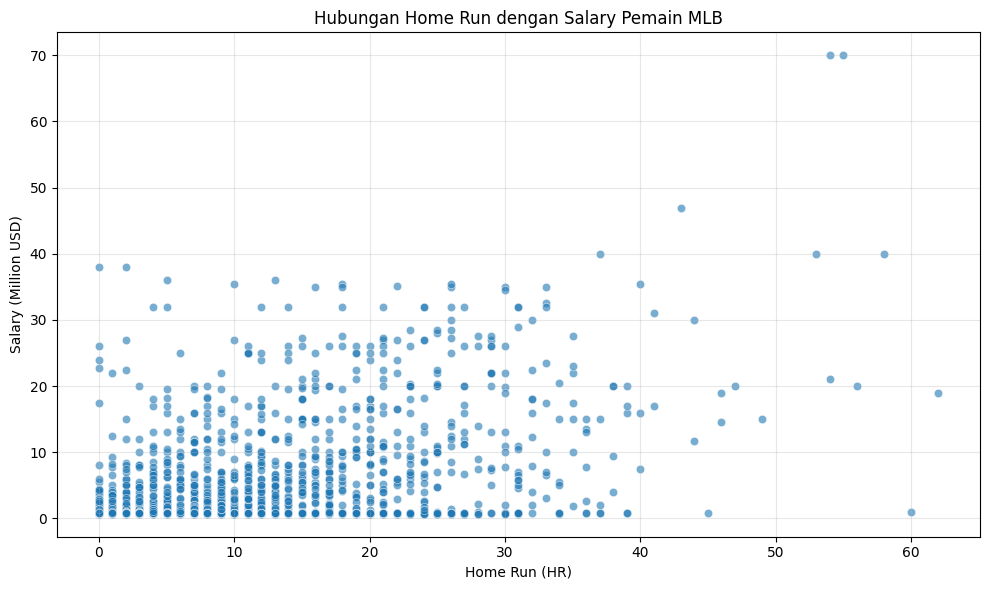

In [22]:
df["Salary_Million"] = df["Salary"] / 1_000_000

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="HR",
    y="Salary_Million",
    alpha=0.6
)

plt.title("Hubungan Home Run dengan Salary Pemain MLB")
plt.xlabel("Home Run (HR)")
plt.ylabel("Salary (Million USD)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

HR sebagai salah satu fitur yang menunjukkan peforma disini menggambarkan bahwa pemain yang memiliki jumlah HR tinggi itu juga akan dibayar dengan lebih tinggi

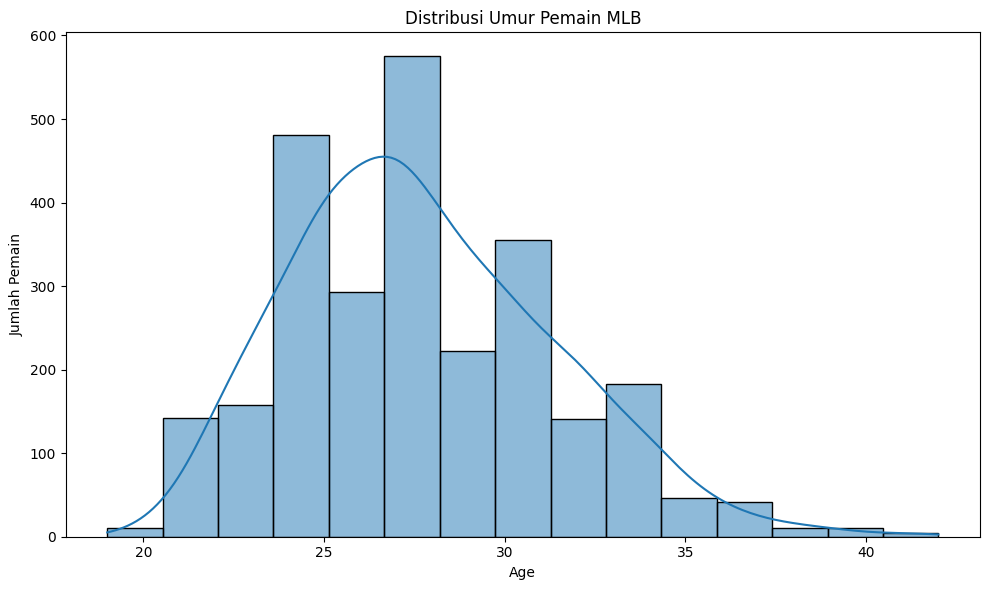

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Distribusi Umur Pemain MLB")
plt.xlabel("Age")
plt.ylabel("Jumlah Pemain")

plt.tight_layout()
plt.show()

untuk distribusi umur tersebut memberi tahu kita bahwa kebanyakan pemain yang aktif itu mulai banyak saat berusia 22 dan mencapai puncaknya ketika umur 28 kemudian disini memberikan gambaran juga bahwa penurunan pemain yang aktif dimulai ketika umur 30 dan penurunan terbesarnya terjadi ketika umurnya diatas 35

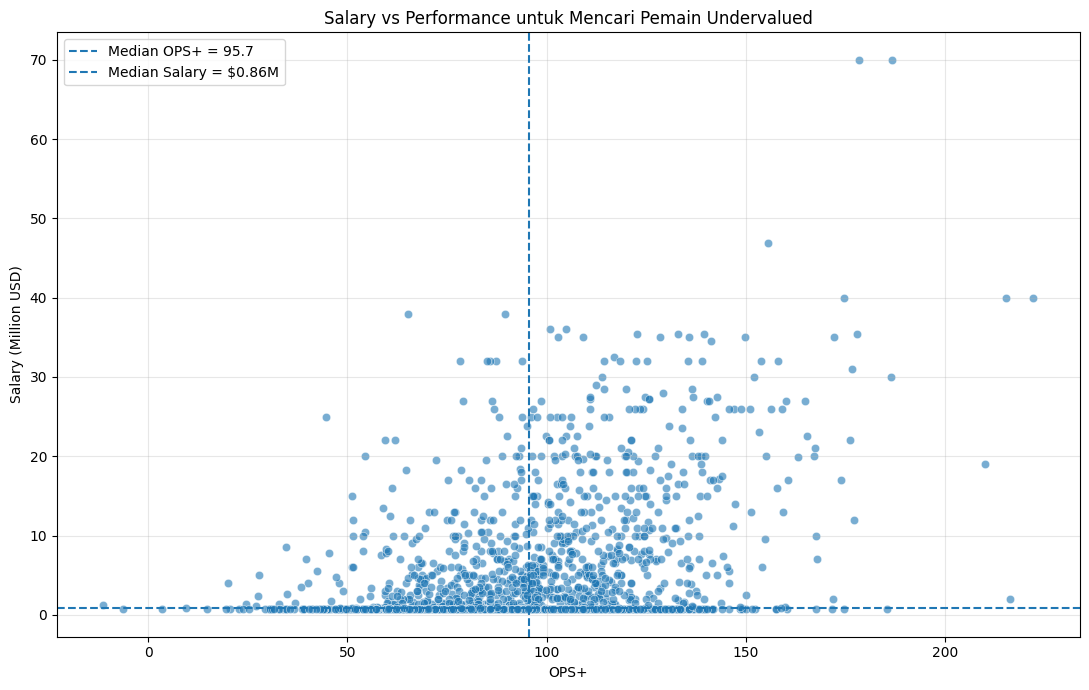

In [25]:
df_value = df[
    (df["PA"] >= 100) &
    (df["OPS+"].notna()) &
    (df["Salary"].notna())
].copy()

# Salary dalam juta USD
df_value["Salary_Million"] = df_value["Salary"] / 1_000_000

# Median salary dan OPS+
median_salary = df_value["Salary_Million"].median()
median_ops = df_value["OPS+"].median()

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_value,
    x="OPS+",
    y="Salary_Million",
    alpha=0.6
)

# Garis pembagi kuadran
plt.axvline(
    median_ops,
    linestyle="--",
    label=f"Median OPS+ = {median_ops:.1f}"
)

plt.axhline(
    median_salary,
    linestyle="--",
    label=f"Median Salary = ${median_salary:.2f}M"
)

plt.title("Salary vs Performance untuk Mencari Pemain Undervalued")
plt.xlabel("OPS+")
plt.ylabel("Salary (Million USD)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
undervalued = df_value[
    (df_value["OPS+"] > median_ops) &
    (df_value["Salary_Million"] < median_salary)
]

undervalued = undervalued[
    [
        "Player",
        "Season",
        "Age",
        "Team",
        "Pos",
        "PA",
        "OPS+",
        "HR",
        "RBI",
        "Salary_Million"
    ]
].sort_values(
    ["OPS+", "Salary_Million"],
    ascending=[False, True]
)

undervalued.head(20)

,Player,Season,Age,Team,Pos,PA,OPS+,HR,RBI,Salary_Million
84,Yordan Alvarez,2022,25,HOU,DH,561,185.6,37,97,0.76460
2151,Nick Kurtz,2025,22,ATH,1B,489,174.8,36,86,0.76000
1110,Davis Schneider,2023,24,TOR,2B,141,171.8,8,20,0.72000
1789,Alex Call,2024,29,WSH,RF,113,167.7,3,14,0.74000
325,Joey Meneses,2022,30,WSH,1B,240,160.4,13,34,0.70000
2391,Jahmai Jones,2025,27,DET,DH,150,159.0,7,23,0.81000
1415,Brent Rooker,2024,29,OAK,DH,614,157.7,39,112,0.75000
1638,Kerry Carpenter,2024,26,DET,RF,296,157.6,18,57,0.76100
874,Nolan Jones,2023,25,COL,LF,424,152.4,20,62,0.72000
2172,Kyle Stowers,2025,27,MIA,LF,457,151.5,25,73,0.76820


dari visualisasi dan sort tersebut itu menggunakan median untuk tahu nilai tengah dari persebaran datanya karena kalau mean sangat rentan terhadap outliers dan disini kita mendapatkan beberapa pemain yang mempunyai kontribusi tinggi tetapi dibayar undervalued